# AI Agent 6 -- RAG + Sliding-Window Memory (Ollama)

Combines two things from the earlier notebooks:
- **Notebook 5 (RAG)**: a `retriever_tool` backed by a Chroma vector store built from a PDF.
- **Notebook 2 (memory)**: a running conversation history so the agent remembers earlier turns.

The twist: instead of sending the *entire* conversation history to the LLM on every turn (which gets slower and more expensive the longer you chat), we only keep the **last 4 human/AI exchanges** in the prompt. Older turns are dropped from the LLM's context but still saved to a full transcript file.

Tool calls/results made during RAG lookups are *not* counted as separate exchanges and are not kept in memory between turns -- only the final human question and the final AI answer of each turn are remembered.

---

### What changed in this version (bug fixes)

| # | Problem | Fix |
|---|---------|-----|
| 1 | `Chroma.from_documents` **re-embedded and re-inserted** every chunk on each run, duplicating the corpus and polluting the top-5 results | Open the collection with `Chroma(...)`, add documents only when empty, and use **deterministic content-hash IDs** so re-adding upserts instead of duplicating. `REBUILD_INDEX` flag forces a clean rebuild. |
| 2 | `llm = llm.bind_tools(tools)` rebound onto the same name, so re-running the cell stacked bindings | Keep `base_llm` separate from the bound `llm`. The cell is now idempotent. |
| 3 | Llama 3.1 sometimes prints tool-call JSON **as plain text**, so `tool_calls` was empty, the graph ended early, and the user saw raw JSON in the answer | `recover_tool_calls()` parses stray JSON out of the content and rebuilds a proper `AIMessage` with structured `tool_calls`. |
| 4 | No recursion guard -- a model stuck in a search loop burned LangGraph's default 25 steps | `RECURSION_LIMIT = 8`, passed via config, with `GraphRecursionError` handled gracefully. |
| 5 | `trim_memory` used a flat `[-8:]` slice, which can start the window on an orphaned `AIMessage` if history ever breaks alternation | Pair-aware trimming: group into Human/AI pairs, drop orphans, keep the last N pairs. |
| 6 | A tool raising an exception crashed the whole run | Tool execution wrapped in `try/except`; the error goes back to the model as a `ToolMessage` so it can recover. |
| 7 | The agent called the retriever for questions about the *conversation* (e.g. "what's my name?"), wasting a round-trip on the PDF | System prompt and tool docstring now say explicitly to answer conversation questions from memory. |
| 8 | Unused imports (`dotenv`, `ChatPromptTemplate`, `Document`, `ToolNode`) | Removed. `START` is now actually used instead of `set_entry_point`. |
| 9 | Loop crashed on empty input and lost the turn on Ctrl-C | Empty input skipped; `KeyboardInterrupt` saves and exits cleanly. |

### New in this version: arithmetic tools

Three more tools are registered alongside `retriever_tool`: **`add`**, **`subtract`** and **`multiply`**. The model now picks between four tools, and can chain them — retrieve two index levels from the PDF, then subtract them, then multiply by 100 for a percentage.

Adding them took **one line** (`tools = [retriever_tool, add, subtract, multiply]`). The graph is structurally identical: `take_action` dispatches by name out of `tools_dict`, so it handles any number of tools, including several called in parallel in a single turn. The tool node is renamed `retriever_agent` → `tool_agent` since it is no longer retrieval-specific, and `RECURSION_LIMIT` went from 8 to 14 to leave room for retrieve-then-compute chains.

The selection is done entirely by the model matching your question against the tool **docstrings** — there is no routing logic in the code. That is why each docstring states what the tool is for *and* what it is not for.

In [1]:
import os
import re
import json
import hashlib
from uuid import uuid4
from typing import Annotated, Sequence, TypedDict

from langchain_core.messages import (
    BaseMessage,      # base class for all message types
    HumanMessage,
    AIMessage,
    ToolMessage,      # result passed back to the LLM after a tool call
    SystemMessage,
)
from langchain_core.tools import tool

from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# FIX 8: dotenv / ChatPromptTemplate / Document / ToolNode were imported but never used -- dropped.
try:
    from langgraph.errors import GraphRecursionError
except ImportError:  # older langgraph versions
    GraphRecursionError = RecursionError

C:\Users\Shaky\AppData\Local\Temp\ipykernel_25624\2789188251.py:18: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


No `.env` / API key needed -- Ollama runs everything locally.
Make sure the Ollama app/service is running and you've pulled the models:

```
ollama pull llama3.1
ollama pull mxbai-embed-large
```

In [2]:
# FIX 2: keep the raw model separate from the tool-bound one.
# Previously `llm = llm.bind_tools(tools)` rebound onto the same name, so re-running that
# cell wrapped an already-wrapped runnable. Now the bind cell below is safe to re-run.
base_llm = ChatOllama(model="llama3.1", temperature=0)  # temperature=0 to minimize hallucination
embeddings = OllamaEmbeddings(model="mxbai-embed-large")

In [3]:
pdf_path = "Stock_Market_Performance_2024.pdf"

if not os.path.exists(pdf_path):
    raise FileNotFoundError(f"The file {pdf_path} does not exist. Please check the path.")

pdf_loader = PyPDFLoader(pdf_path)

try:
    pages = pdf_loader.load()
    print(f"PDF has been loaded and has {len(pages)} pages")
except Exception as e:
    print(f"Error loading PDF: {e}")
    raise

PDF has been loaded and has 9 pages


In [4]:
# Chunking
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
pages_split = text_splitter.split_documents(pages)
print(f"Split into {len(pages_split)} chunks")

Split into 24 chunks


### FIX 1 -- the vector store is now idempotent

The original cell called `Chroma.from_documents(...)` every time. That **inserts**, it does not upsert, so every re-run appended a fresh copy of the whole document to the persisted collection. After three runs the store held three copies and `k=5` started returning near-duplicate chunks, crowding out genuinely different context.

Two changes:
- The collection is **opened** with `Chroma(...)` rather than rebuilt, and documents are added only when it is empty.
- Every chunk gets a **deterministic ID** derived from a SHA-1 of its text plus its source and page. `add_documents` with explicit IDs upserts, so even a forced re-add overwrites in place instead of duplicating.

Set `REBUILD_INDEX = True` to wipe and rebuild -- do that if you change the PDF, the chunk settings, or the embedding model.

In [5]:
persist_directory = "./chroma_langchain_db"
collection_name = "stock_market"

REBUILD_INDEX = False  # flip to True to wipe and re-embed from scratch

os.makedirs(persist_directory, exist_ok=True)


def make_chunk_ids(docs) -> list:
    "Deterministic IDs so re-adding the same chunk upserts instead of duplicating."
    ids = []
    for i, doc in enumerate(docs):
        digest = hashlib.sha1(doc.page_content.encode("utf-8")).hexdigest()[:16]
        source = os.path.basename(str(doc.metadata.get("source", "unknown")))
        page = doc.metadata.get("page", "?")
        ids.append(f"{source}:p{page}:{i}:{digest}")
    return ids


try:
    vectorstore = Chroma(
        persist_directory=persist_directory,
        collection_name=collection_name,
        embedding_function=embeddings,
    )

    existing = vectorstore._collection.count()

    if REBUILD_INDEX and existing:
        vectorstore.delete_collection()
        vectorstore = Chroma(
            persist_directory=persist_directory,
            collection_name=collection_name,
            embedding_function=embeddings,
        )
        existing = 0
        print("Existing collection deleted (REBUILD_INDEX=True).")

    if existing == 0:
        vectorstore.add_documents(documents=pages_split, ids=make_chunk_ids(pages_split))
        print(f"Created ChromaDB vector store with {vectorstore._collection.count()} chunks!")
    else:
        print(f"Reusing existing ChromaDB collection ({existing} chunks) -- no re-embedding needed.")
        print("Set REBUILD_INDEX = True if the PDF, chunk settings or embedding model changed.")

except Exception as e:
    print(f"Error setting up ChromaDB: {str(e)}")
    raise

Reusing existing ChromaDB collection (96 chunks) -- no re-embedding needed.
Set REBUILD_INDEX = True if the PDF, chunk settings or embedding model changed.


In [6]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5},  # number of chunks to return
)

In [7]:
@tool
def retriever_tool(query: str) -> str:
    "Search the Stock Market Performance 2024 PDF and return the most relevant passages. Use this for questions about stocks, indices, sectors, returns, or any other content of that document. Do NOT use it for questions about this conversation itself (the user's name, earlier answers) -- that is already in your context."
    docs = retriever.invoke(query)
    if not docs:
        return "I found no relevant information in the Stock Market Performance 2024 document."

    results = []
    for i, doc in enumerate(docs):
        page = doc.metadata.get("page", "?")
        results.append(f"Document {i + 1} (page {page}):\n{doc.page_content}")

    return "\n\n".join(results)


@tool
def add(a: float, b: float) -> float:
    "Add two numbers together and return a + b. Use this whenever the user asks for a sum or a total. Do NOT use it to look up figures -- fetch those with retriever_tool first, then add them with this."
    return a + b


@tool
def subtract(a: float, b: float) -> float:
    "Subtract the second number from the first and return a - b. Use this for differences, drops, gains, or how much larger one value is than another. Do NOT use it to look up figures -- fetch those with retriever_tool first, then subtract them with this."
    return a - b


@tool
def multiply(a: float, b: float) -> float:
    "Multiply two numbers together and return a * b. Use this for products, for scaling a value, or for applying a multiplier or a rate. Do NOT use it to look up figures -- fetch those with retriever_tool first, then multiply them with this."
    return a * b


# Adding a tool is a one-line change: everything downstream (tools_dict, bind_tools,
# take_action's dispatch loop) is built from this list, so the graph needs no edits.
tools = [retriever_tool, add, subtract, multiply]
tools_dict = {t.name: t for t in tools}

# FIX 2: bind onto `base_llm`, not onto `llm` itself -- this cell is now safe to re-run.
# bind_tools ships the JSON schema of ALL FOUR tools (name + docstring + arg types) with
# every request. The model picks by matching the question against those docstrings --
# there is no selection logic anywhere in this notebook.
llm = base_llm.bind_tools(tools)

print("Tools registered:", list(tools_dict))

Tools registered: ['retriever_tool', 'add', 'subtract', 'multiply']


In [8]:
class AgentState(TypedDict):
    # add_messages appends new messages to this list in the correct order instead of overwriting it
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [9]:
# FIX 7: the old prompt never said when NOT to search, so the model fired the retriever at the
# PDF for questions like "what is my name?" -- burning a full round-trip on irrelevant chunks.
system_prompt = (
    "You are an intelligent AI assistant who answers questions about Stock Market Performance in 2024 "
    "based on the PDF document loaded into your knowledge base, and you also remember the recent "
    "conversation with the user.\n\n"
    "You have a retriever tool for the document and add / subtract / multiply tools for arithmetic. "
    "Choose whichever tools the question needs. You may call several in sequence: look figures up with "
    "the retriever first, then feed those numbers into the arithmetic tools. Never do arithmetic in your "
    "head -- use the tools, they are exact.\n\n"
    "Do NOT use any tool for questions about this conversation itself -- the user's name, what they told "
    "you earlier, or what you already answered. That is in your message history; answer it directly.\n\n"
    "Always cite the specific parts of the documents you use in your answers."
)


def should_continue(state: AgentState) -> bool:
    "Check if the last message contains tool calls."
    result = state["messages"][-1]
    return hasattr(result, "tool_calls") and len(result.tool_calls) > 0

### FIX 3 -- recovering tool calls the model emitted as plain text

Llama 3.1 through Ollama sometimes writes the tool call into its *visible answer* instead of the structured tool-calling channel, e.g.

```
{"name": "retriever_tool", "parameters": {"query": "Nasdaq 2024"}}
```

When that happens `AIMessage.tool_calls` is empty, `should_continue` returns `False`, the graph goes straight to `END`, and the user sees raw JSON instead of an answer. This is exactly what happened in the original notebook's saved output.

`recover_tool_calls()` catches it: brace-match JSON objects inside the content, check whether the `name` field matches a registered tool, and if so rebuild a proper `AIMessage` with structured `tool_calls` (stripping the JSON out of the visible text). The graph then loops as intended. It accepts `parameters`, `arguments`, or `args` as the key holding the arguments, since the model is not consistent about which it uses.

In [10]:
def _extract_json_objects(text: str) -> list:
    "Find top-level {...} blocks in text and parse the ones that are valid JSON objects."
    found = []
    depth = 0
    start = None
    for i, ch in enumerate(text):
        if ch == "{":
            if depth == 0:
                start = i
            depth += 1
        elif ch == "}" and depth > 0:
            depth -= 1
            if depth == 0 and start is not None:
                try:
                    obj = json.loads(text[start:i + 1])
                    if isinstance(obj, dict):
                        found.append((start, i + 1, obj))
                except json.JSONDecodeError:
                    pass
                start = None
    return found


def recover_tool_calls(message: AIMessage) -> AIMessage:
    "Rebuild structured tool_calls when the model printed them as text instead."
    if getattr(message, "tool_calls", None):
        return message  # already fine

    text = message.content if isinstance(message.content, str) else ""
    if not text or "{" not in text:
        return message

    recovered, spans = [], []
    for start, end, obj in _extract_json_objects(text):
        name = obj.get("name")
        if name not in tools_dict:
            continue

        args = obj.get("parameters") or obj.get("arguments") or obj.get("args") or {}
        if isinstance(args, str):
            try:
                args = json.loads(args)
            except json.JSONDecodeError:
                args = {"query": args}
        if not isinstance(args, dict):
            args = {"query": str(args)}

        recovered.append({
            "name": name,
            "args": args,
            "id": f"recovered_{uuid4().hex[:8]}",
            "type": "tool_call",
        })
        spans.append((start, end))

    if not recovered:
        return message

    cleaned = text
    for start, end in reversed(spans):
        cleaned = cleaned[:start] + cleaned[end:]
    cleaned = re.sub(r"\n{3,}", "\n\n", cleaned).strip()

    print(f"[recovered] model emitted {len(recovered)} tool call(s) as plain text -- converted to real calls.")
    return AIMessage(content=cleaned, tool_calls=recovered, id=message.id)

In [11]:
def call_llm(state: AgentState) -> AgentState:
    "Call the LLM with the current state."
    messages = [SystemMessage(content=system_prompt)] + list(state["messages"])
    message = llm.invoke(messages)
    message = recover_tool_calls(message)  # FIX 3
    return {"messages": [message]}


def take_action(state: AgentState) -> AgentState:
    "Execute tool calls requested by the LLM."
    tool_calls = state["messages"][-1].tool_calls
    results = []

    for t in tool_calls:
        print(f"Calling Tool: {t['name']} with args: {t['args']}")

        if t["name"] not in tools_dict:
            print(f"\nTool: {t['name']} does not exist.")
            result = "Incorrect Tool Name, Please Retry and Select tool from List of Available tools."
        else:
            # FIX 6: a raising tool used to kill the whole run. Now the error is handed back to
            # the model as a ToolMessage so it can retry with different arguments.
            try:
                result = tools_dict[t["name"]].invoke(t["args"])
                print(f"Result length: {len(str(result))}")
            except Exception as e:
                result = f"Tool '{t['name']}' failed with error: {e}. Try rephrasing the query."
                print(f"Tool error: {e}")

        results.append(ToolMessage(tool_call_id=t["id"], name=t["name"], content=str(result)))

    print("Tools Execution Complete. Back to the model!")
    return {"messages": results}

In [12]:
# FIX 4: cap how many llm <-> tool_agent hops a single question may take.
# LangGraph's default is 25, which lets a confused model burn ~12 tool calls before erroring.
# Raised from 8 to 14 now that there are four tools: a "retrieve two figures, then subtract,
# then multiply" chain needs ~4 round-trips, and 8 left no headroom for a retry.
RECURSION_LIMIT = 14

# The graph itself is UNCHANGED by adding tools -- take_action dispatches by name out of
# tools_dict, so one tool or four makes no difference to the topology. Recompiled here so the
# compiled object is rebuilt after the new tool registrations above.
graph = StateGraph(AgentState)
graph.add_node("llm", call_llm)
graph.add_node("tool_agent", take_action)  # renamed from retriever_agent: it now runs any tool

graph.add_edge(START, "llm")  # FIX 8: use START instead of set_entry_point
graph.add_conditional_edges("llm", should_continue, {True: "tool_agent", False: END})
graph.add_edge("tool_agent", "llm")

rag_agent = graph.compile()
print("Graph compiled with tools:", list(tools_dict))

Graph compiled with tools: ['retriever_tool', 'add', 'subtract', 'multiply']


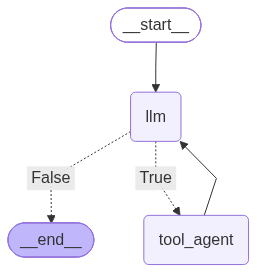

In [13]:
try:
    from IPython.display import Image, display
    display(Image(rag_agent.get_graph().draw_mermaid_png()))
except Exception as e:
    # draw_mermaid_png calls out to mermaid.ink -- fall back to ASCII if offline
    print(f"(mermaid render unavailable: {e})\n")
    rag_agent.get_graph().print_ascii()

## Sliding-window memory, persisted across runs

`full_history` holds every `HumanMessage`/`AIMessage` pair from the conversation so far (no intermediate tool calls or results -- those stay internal to a single `rag_agent.invoke()` run). It is loaded from `conversation_memory.json` when `running_agent()` starts and saved back after **every** turn, so re-running this notebook, or restarting the kernel, does **not** lose earlier conversations.

Before every LLM call, `trim_memory()` slices `full_history` down to the last `MAX_EXCHANGES` pairs, so the prompt stays a fixed, small size no matter how long the conversation has grown.

**FIX 5:** the old `trim_memory` was a flat `memory[-8:]`. If the history ever stopped alternating strictly -- an interrupted turn, a hand-edited JSON file, a run that saved a Human with no AI reply -- that slice could begin on an orphaned `AIMessage`, giving the model a context window that opens mid-answer with no question attached. The new version groups history into Human/AI pairs, drops orphans, then keeps the last N pairs, so the window is always well-formed.

`logging.txt` is a human-readable transcript regenerated from the *complete* `full_history` after every turn.

In [14]:
MAX_EXCHANGES = 4  # how many human/AI turn-pairs to keep in the LLM's context
MEMORY_FILE = "conversation_memory.json"  # persists the full history across notebook runs
LOG_FILE = "logging.txt"


def trim_memory(memory: list, max_exchanges: int = MAX_EXCHANGES) -> list:
    "Keep only the last `max_exchanges` well-formed HumanMessage/AIMessage pairs. FIX 5: pair-aware instead of a flat tail slice, so the window can never start on an orphaned AIMessage."
    pairs = []
    i = 0
    while i < len(memory):
        current = memory[i]
        nxt = memory[i + 1] if i + 1 < len(memory) else None
        if isinstance(current, HumanMessage) and isinstance(nxt, AIMessage):
            pairs.append((current, nxt))
            i += 2
        else:
            i += 1  # drop the orphan and resync

    kept = pairs[-max_exchanges:]
    return [m for pair in kept for m in pair]


def load_memory() -> list:
    "Load the full conversation history saved by a previous run, if any."
    if not os.path.exists(MEMORY_FILE):
        return []
    try:
        with open(MEMORY_FILE, "r", encoding="utf-8") as f:
            raw = json.load(f)
    except (json.JSONDecodeError, OSError) as e:
        print(f"Could not read {MEMORY_FILE} ({e}) -- starting a fresh history.")
        return []

    messages = []
    for item in raw:
        content = item.get("content", "")
        if item.get("role") == "human":
            messages.append(HumanMessage(content=content))
        else:
            messages.append(AIMessage(content=content))
    return messages


def save_memory(full_history: list) -> None:
    "Persist the full conversation history to disk so future runs can load it back."
    raw = [
        {"role": "human" if isinstance(m, HumanMessage) else "ai", "content": m.content}
        for m in full_history
    ]
    with open(MEMORY_FILE, "w", encoding="utf-8") as f:
        json.dump(raw, f, indent=2)


def write_log(full_history: list) -> None:
    "Regenerate the human-readable transcript from the complete history."
    with open(LOG_FILE, "w", encoding="utf-8") as f:
        f.write("Your Conversation Log:\n")
        for message in full_history:
            if isinstance(message, HumanMessage):
                f.write(f"You: {message.content}\n")
            elif isinstance(message, AIMessage):
                f.write(f"AI: {message.content}\n\n")

In [15]:
def _final_answer(result: dict) -> str:
    "Pull the last AIMessage that actually has text out of the graph result, so a run ending on a ToolMessage or an empty tool-call message does not write a blank answer into memory."
    for message in reversed(result["messages"]):
        if isinstance(message, AIMessage) and isinstance(message.content, str) and message.content.strip():
            return message.content
    return "(no answer produced)"


def running_agent():
    print("\n=== RAG AGENT (persistent memory, last 4 exchanges used for context) ===")

    full_history = load_memory()  # everything remembered from all previous runs
    if full_history:
        print(f"Loaded {len(full_history) // 2} previous exchange(s) from {MEMORY_FILE}.")

    while True:
        try:
            user_input = input("\nWhat is your question: ")
        except (KeyboardInterrupt, EOFError):  # FIX 9: Ctrl-C exits cleanly, history already saved
            print("\nInterrupted.")
            break

        if user_input.strip().lower() in ["exit", "quit"]:
            break
        if not user_input.strip():  # FIX 9: never send an empty turn to the model
            continue

        human_message = HumanMessage(content=user_input)

        # Only the trimmed recent history + the new question goes to the agent
        context = trim_memory(full_history) + [human_message]

        # FIX 4: bound the llm <-> retriever loop instead of relying on the default 25
        try:
            result = rag_agent.invoke(
                {"messages": context},
                config={"recursion_limit": RECURSION_LIMIT},
            )
            answer = _final_answer(result)
        except GraphRecursionError:
            print(f"\n[recursion limit of {RECURSION_LIMIT} reached -- aborting this turn]")
            answer = (
                f"I got stuck looping between the model and the tools and hit the "
                f"{RECURSION_LIMIT}-step limit. Try asking a narrower question."
            )

        print("\n=== ANSWER ===")
        print(answer)

        # Full history keeps growing; only the final Q/A pair is kept per turn
        # (tool calls/results are not persisted between turns)
        full_history.append(human_message)
        full_history.append(AIMessage(content=answer))

        # Save after every turn so nothing is lost even if you interrupt the kernel
        save_memory(full_history)
        write_log(full_history)

    print(f"\nConversation saved to {MEMORY_FILE} and {LOG_FILE}")

In [16]:
running_agent()


=== RAG AGENT (persistent memory, last 4 exchanges used for context) ===
Loaded 9 previous exchange(s) from conversation_memory.json.
Calling Tool: multiply with args: {'a': '45', 'b': '3'}
Result length: 5
Tools Execution Complete. Back to the model!

=== ANSWER ===
The result of multiplying 45 by 3 is 135.
[recovered] model emitted 2 tool call(s) as plain text -- converted to real calls.
Calling Tool: multiply with args: {'a': 135, 'b': 18}
Result length: 6
Calling Tool: subtract with args: {'a': 'result of previous function call', 'b': 250}
Tool error: 1 validation error for subtract
a
  Input should be a valid number, unable to parse string as a number [type=float_parsing, input_value='result of previous function call', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/float_parsing
Tools Execution Complete. Back to the model!

=== ANSWER ===
To perform the calculation, I need to first multiply 135 by 18.

The result of multiplying 135 by 18 is 2